# Overtake Analysis

Analyses historical race overtake counts (2023–2026) to understand their distribution and inform fantasy scoring.

**Context:** Overtakes are currently missing from the target computation - each on-track overtake scores +1 point for the driver (and sprint overtakes also score +1). This notebook:
1. Validates the manual overtake data against computed target gaps
2. Explores the distribution by driver, circuit, and season
3. Informs how to model expected overtakes as a feature for future prediction

**Data sources:**
- `data/manual/race_overtakes/` - scraped from F1 Fantasy statistics site (2023–2025)
- 2026 R5 validated manually against known fantasy scores

In [91]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

from app.config import INTERIM_RACES_DIR, INTERIM_EVENTS_DIR, PROCESSED_TARGETS_DIR

OT_DIR = Path('../data/manual/race_overtakes')

## Load overtake data

In [92]:
frames = []
for f in sorted(OT_DIR.glob('*.csv')):
    season, round_ = f.stem.split('_')
    df = pd.read_csv(f)
    df['season'] = int(season)
    df['round'] = int(round_)
    frames.append(df)

ot = pd.concat(frames).reset_index(drop=True)

print(f"Seasons: {sorted(ot['season'].unique())}")
print(f"Total rows: {len(ot)}")
print(f"Drivers: {ot['driver_id'].nunique()}")
print(f"\nOvertakes per race summary:")
print(ot.groupby('season')['race_overtakes'].describe().round(2))

Seasons: [np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
Total rows: 1508
Drivers: 29

Overtakes per race summary:
        count  mean   std  min  25%  50%   75%   max
season                                              
2023    440.0  4.50  3.64  0.0  2.0  4.0  6.00  20.0
2024    478.0  3.59  2.74  0.0  2.0  3.0  5.00  14.0
2025    480.0  3.30  2.91  0.0  1.0  3.0  5.00  16.0
2026    110.0  5.34  3.76  0.0  3.0  5.0  7.75  20.0


## Distribution of overtakes per driver per race

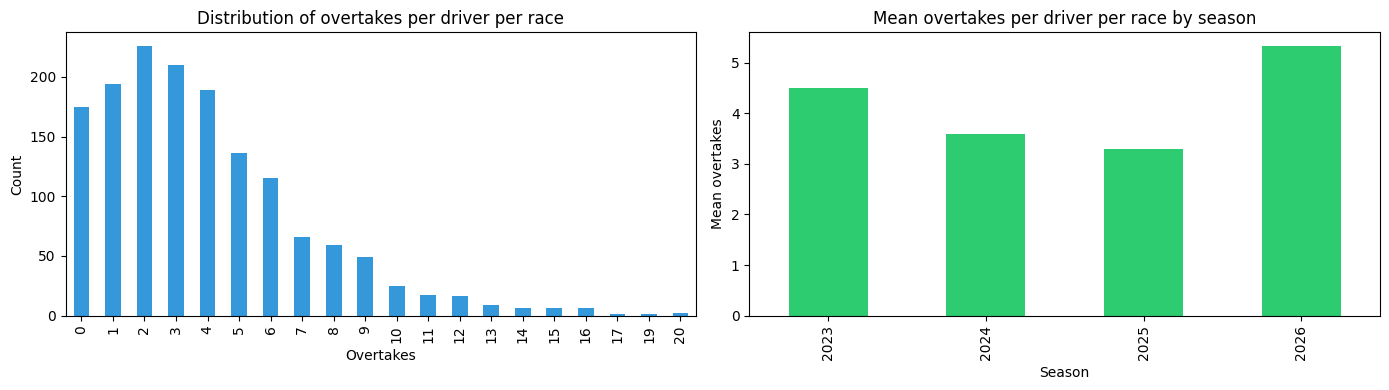


Median overtakes: 3.0
Mean overtakes: 3.89
Pct with 0 overtakes: 11.6%
Pct with 5+ overtakes: 34.1%


In [93]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# overall distribution
ot['race_overtakes'].value_counts().sort_index().head(20).plot(
    kind='bar', ax=axes[0], color='#3498db'
)
axes[0].set_title('Distribution of overtakes per driver per race')
axes[0].set_xlabel('Overtakes')
axes[0].set_ylabel('Count')

# by season
ot.groupby('season')['race_overtakes'].mean().plot(
    kind='bar', ax=axes[1], color='#2ecc71'
)
axes[1].set_title('Mean overtakes per driver per race by season')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Mean overtakes')

plt.tight_layout()
plt.show()

print(f"\nMedian overtakes: {ot['race_overtakes'].median():.1f}")
print(f"Mean overtakes: {ot['race_overtakes'].mean():.2f}")
print(f"Pct with 0 overtakes: {(ot['race_overtakes'] == 0).mean():.1%}")
print(f"Pct with 5+ overtakes: {(ot['race_overtakes'] >= 5).mean():.1%}")

## Top overtakers - career averages

In [94]:
driver_avg = (
    ot.groupby('driver_id')['race_overtakes']
    .agg(['mean', 'sum', 'count'])
    .rename(columns={'mean': 'avg_per_race', 'sum': 'total', 'count': 'races'})
    .query('races >= 10')  # min 10 races for stable estimate
    .sort_values('avg_per_race', ascending=False)
)

print(driver_avg.round(2).to_string())

                       avg_per_race  total  races
driver_id                                        
sergio_perez                   5.29    270     51
oliver_bearman                 5.23    162     31
kevin_magnussen                4.98    219     44
lewis_hamilton                 4.47    335     75
lance_stroll                   4.44    333     75
alexander_albon                4.24    318     75
esteban_ocon                   4.20    311     74
nico_hulkenberg                4.16    312     75
yuki_tsunoda                   4.10    287     70
zhou_guanyu                    3.93    181     46
oscar_piastri                  3.93    295     75
george_russell                 3.87    290     75
fernando_alonso                3.85    289     75
pierre_gasly                   3.80    285     75
andrea_kimi_antonelli          3.79    110     29
liam_lawson                    3.70    148     40
carlos_sainz                   3.65    270     74
max_verstappen                 3.60    270     75


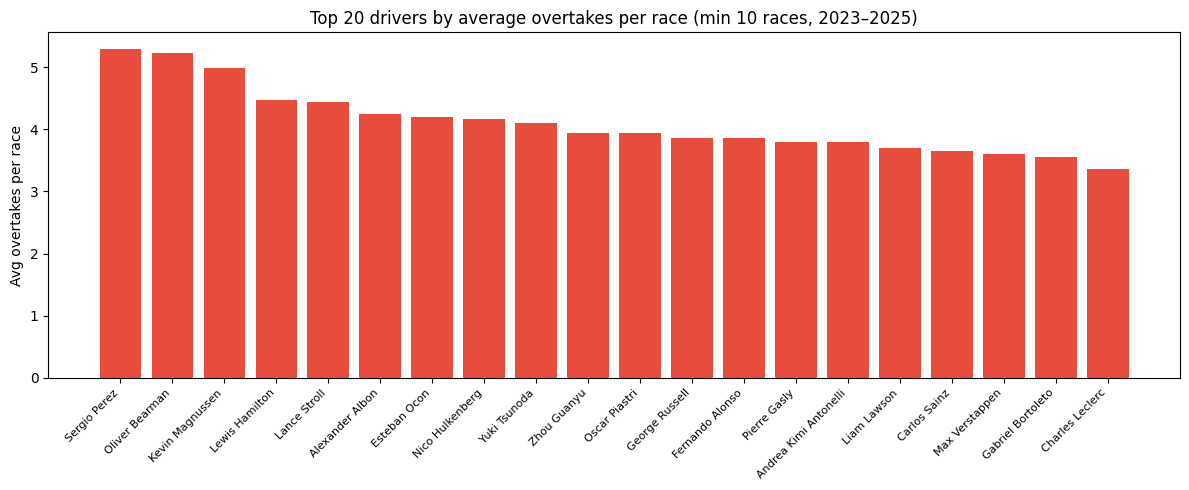

In [95]:
top20 = driver_avg.head(20)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(len(top20)), top20['avg_per_race'], color='#e74c3c')
ax.set_xticks(range(len(top20)))
ax.set_xticklabels(
    [d.replace('_', ' ').title() for d in top20.index],
    rotation=45, ha='right', fontsize=8
)
ax.set_title('Top 20 drivers by average overtakes per race (min 10 races, 2023–2025)')
ax.set_ylabel('Avg overtakes per race')
plt.tight_layout()
plt.show()

## Overtakes relative to season average

Raw overtake counts are season-dependent (2023 avg ~4.5, 2025 avg ~3.3). To compare drivers fairly across seasons we normalise each driver-race by the season mean - giving an **overtake index** where 1.0 = exactly average, >1 = above average.

In [96]:
# compute season mean and normalise
season_mean = ot.groupby('season')['race_overtakes'].transform('mean')
ot['overtake_index'] = ot['race_overtakes'] / season_mean

# per-driver overtake index (min 10 races)
driver_index = (
    ot.groupby('driver_id')
    .agg(
        avg_raw=('race_overtakes', 'mean'),
        avg_index=('overtake_index', 'mean'),
        races=('race_overtakes', 'count'),
    )
    .query('races >= 10')
    .sort_values('avg_index', ascending=False)
)

print(driver_index.round(3).to_string())

                       avg_raw  avg_index  races
driver_id                                       
oliver_bearman           5.226      1.453     31
sergio_perez             5.294      1.283     51
kevin_magnussen          4.977      1.253     44
lance_stroll             4.440      1.168     75
lewis_hamilton           4.467      1.168     75
alexander_albon          4.240      1.114     75
nico_hulkenberg          4.160      1.097     75
esteban_ocon             4.203      1.079     74
yuki_tsunoda             4.100      1.068     70
andrea_kimi_antonelli    3.793      1.057     29
fernando_alonso          3.853      1.003     75
oscar_piastri            3.933      0.994     75
liam_lawson              3.700      0.979     40
gabriel_bortoleto        3.552      0.976     29
george_russell           3.867      0.973     75
pierre_gasly             3.800      0.966     75
zhou_guanyu              3.935      0.956     46
carlos_sainz             3.649      0.947     74
max_verstappen      

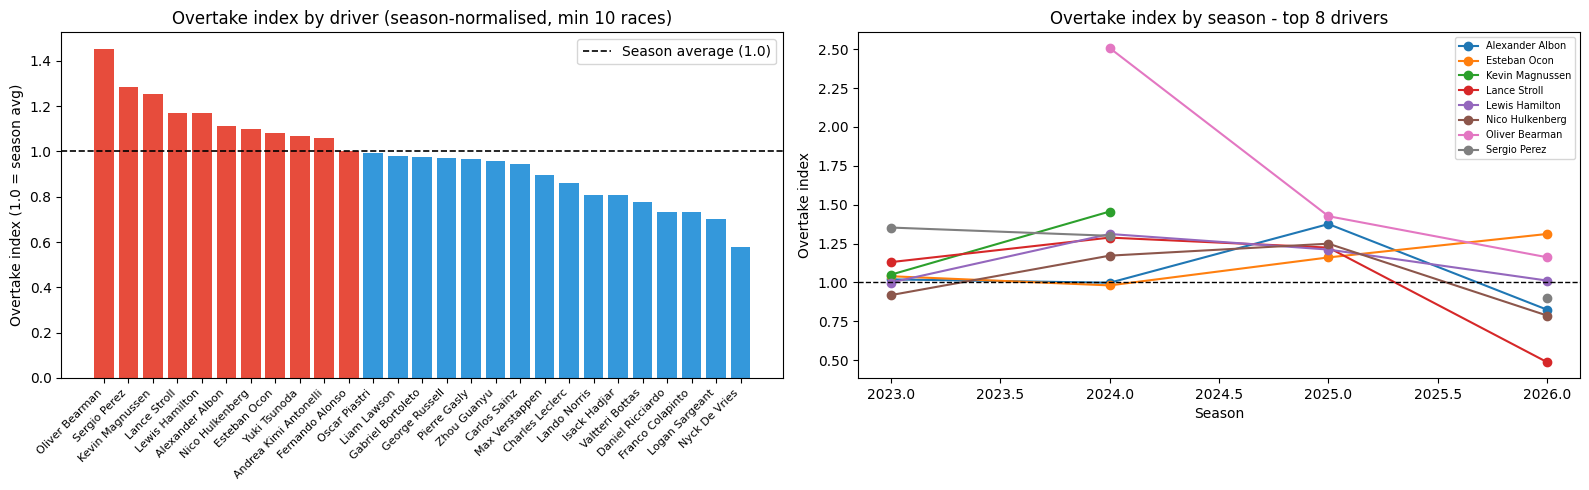

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# left: overtake index bar chart, red = above avg, blue = below
colours = ['#e74c3c' if v > 1 else '#3498db' for v in driver_index['avg_index']]
axes[0].bar(range(len(driver_index)), driver_index['avg_index'], color=colours)
axes[0].axhline(1.0, color='black', linewidth=1.2, linestyle='--', label='Season average (1.0)')
axes[0].set_xticks(range(len(driver_index)))
axes[0].set_xticklabels(
    [d.replace('_', ' ').title() for d in driver_index.index],
    rotation=45, ha='right', fontsize=8
)
axes[0].set_title('Overtake index by driver (season-normalised, min 10 races)')
axes[0].set_ylabel('Overtake index (1.0 = season avg)')
axes[0].legend()

# right: season-by-season index for top 8 drivers
top8 = driver_index.head(8).index.tolist()
season_driver = (
    ot[ot['driver_id'].isin(top8)]
    .groupby(['season', 'driver_id'])['overtake_index']
    .mean()
    .unstack('driver_id')
)
season_driver.columns = [c.replace('_', ' ').title() for c in season_driver.columns]
season_driver.plot(ax=axes[1], marker='o', linewidth=1.5)
axes[1].axhline(1.0, color='black', linewidth=1, linestyle='--')
axes[1].set_title('Overtake index by season - top 8 drivers')
axes[1].set_ylabel('Overtake index')
axes[1].set_xlabel('Season')
axes[1].legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.show()

## Overtake points contribution to total fantasy score

At +1 point per overtake, how much do overtakes contribute relative to other scoring components?

In [98]:
# load computed targets (excl. overtakes) for comparison
targets = pd.concat([
    pd.read_parquet(f) for f in sorted(PROCESSED_TARGETS_DIR.glob('202[34]_*.parquet'))
]).reset_index(drop=True)

drivers_targets = (
    targets[targets['asset_type'] == 'driver']
    .rename(columns={'asset_id': 'driver_id'})
    .copy()
)

# merge overtakes onto targets
merged = drivers_targets.merge(
    ot.rename(columns={'race_overtakes': 'overtakes'}),
    on=['season', 'round', 'driver_id'],
    how='inner'
)

merged['pct_from_overtakes'] = merged['overtakes'] / (merged['actual_fantasy_points'] + merged['overtakes']).replace(0, np.nan)

print(f"Matched {len(merged)} driver-race records")
print(f"\nMean overtake points per race: {merged['overtakes'].mean():.2f}")
print(f"Mean computed base points per race: {merged['actual_fantasy_points'].mean():.2f}")
print(f"Overtakes as % of total (base + overtakes): {merged['pct_from_overtakes'].mean():.1%}")

Matched 866 driver-race records

Mean overtake points per race: 4.02
Mean computed base points per race: 7.26
Overtakes as % of total (base + overtakes): 33.9%


## Circuit-level overtake rates

Some circuits naturally produce more overtakes. This is useful context for feature engineering.

In [99]:
# load event metadata to get circuit locations
events = pd.concat([
    pd.read_parquet(f) for f in sorted(INTERIM_EVENTS_DIR.glob('202[345]_*.parquet'))
]).reset_index(drop=True)

# per-race totals with driver count, so we can normalise
race_totals = (
    ot.groupby(['season', 'round'])
    .agg(total_overtakes=('race_overtakes', 'sum'), driver_count=('race_overtakes', 'count'))
    .reset_index()
)

# season mean per-driver overtakes for normalisation
season_avg = ot.groupby('season')['race_overtakes'].mean().rename('season_avg')
race_totals = race_totals.join(season_avg, on='season')

# overtake index: this race's per-driver avg relative to season per-driver avg
race_totals['per_driver_avg'] = race_totals['total_overtakes'] / race_totals['driver_count']
race_totals['overtake_index'] = race_totals['per_driver_avg'] / race_totals['season_avg']

race_totals = race_totals.merge(
    events[['season', 'round', 'location', 'is_street_circuit']].drop_duplicates(),
    on=['season', 'round'],
    how='left'
)

circuit_index = (
    race_totals.groupby('location')
    .agg(avg_index=('overtake_index', 'mean'), races=('overtake_index', 'count'))
    .query('races >= 2')
    .sort_values('avg_index', ascending=False)
)

print(circuit_index.round(3).to_string())

                   avg_index  races
location                           
Zandvoort              1.531      3
Yas Island             1.489      3
Las Vegas              1.348      3
Mexico City            1.341      3
Sakhir                 1.259      3
Shanghai               1.228      2
Spielberg              1.215      3
Barcelona              1.212      3
Miami                  1.197      3
Austin                 1.042      3
São Paulo              1.032      3
Lusail                 0.994      3
Marina Bay             0.900      3
Montréal               0.892      3
Spa-Francorchamps      0.882      3
Imola                  0.830      2
Budapest               0.820      3
Monza                  0.814      3
Suzuka                 0.804      3
Baku                   0.764      3
Jeddah                 0.734      3
Silverstone            0.724      3
Melbourne              0.710      3
Monaco                 0.256      3


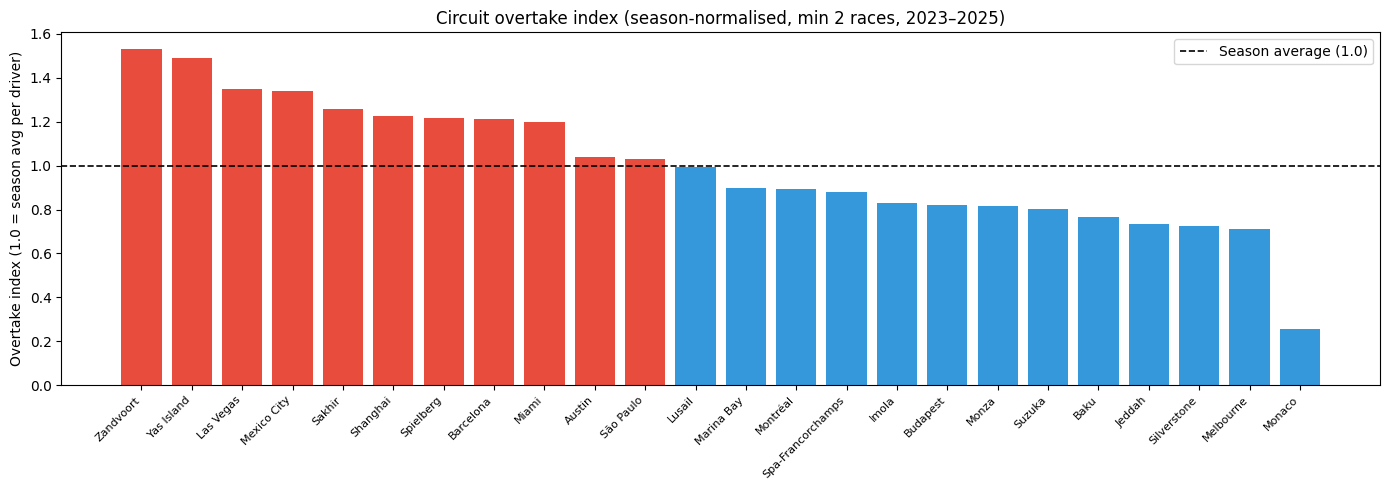

In [100]:
colours = ['#e74c3c' if v > 1 else '#3498db' for v in circuit_index['avg_index']]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(circuit_index)), circuit_index['avg_index'], color=colours)
ax.axhline(1.0, color='black', linewidth=1.2, linestyle='--', label='Season average (1.0)')
ax.set_xticks(range(len(circuit_index)))
ax.set_xticklabels(circuit_index.index, rotation=45, ha='right', fontsize=8)
ax.set_title('Circuit overtake index (season-normalised, min 2 races, 2023–2025)')
ax.set_ylabel('Overtake index (1.0 = season avg per driver)')
ax.legend()
plt.tight_layout()
plt.show()

## Expected overtake model

For the ILP we need a single **expected overtake count** per driver for the race being predicted.

Simple averaging fails because track variance dominates (Monaco ~0.3×, China ~2×). Instead we use a multiplicative model:

```
expected(driver, circuit, season) = driver_index × circuit_index × season_mean
```

Both indices are season-normalised (1.0 = average), so they compose cleanly. Edge cases:
- Unknown driver → `driver_index = 1.0` (treat as average)
- Unknown circuit → `circuit_index = 1.0` (treat as average)
- Prediction season with no data yet → fall back to most recent season mean

In [101]:
# season baselines
season_means = ot.groupby('season')['race_overtakes'].mean().to_dict()
print("Season means:", {s: round(v, 2) for s, v in season_means.items()})

# lookup series - .get() defaults to 1.0 for unknowns
d_idx = driver_index['avg_index']
c_idx = circuit_index['avg_index']

def predict_overtakes(driver_id: str, location: str, season: int) -> float:
    """
    Expected overtakes for a driver at a circuit in a given season.
    Uses multiplicative model: driver_index × circuit_index × season_mean.
    Falls back to index=1.0 for unknown drivers/circuits.
    """
    d = d_idx.get(driver_id, 1.0)
    c = c_idx.get(location, 1.0)
    s = season_means.get(season, season_means[max(season_means)])
    return round(d * c * s, 2)

# demo: 2026 grid across highest/lowest overtaking circuits
drivers_2026 = sorted(ot[ot['season'] == 2026]['driver_id'].unique())
demo_circuits = (
    circuit_index.head(3).index.tolist() +   # highest overtake tracks
    circuit_index.tail(3).index.tolist()     # lowest overtake tracks
)

rows = []
for driver in drivers_2026:
    row = {'driver': driver}
    for circuit in demo_circuits:
        row[circuit] = predict_overtakes(driver, circuit, 2026)
    rows.append(row)

demo = pd.DataFrame(rows).set_index('driver')
# sort by middle-of-range circuit as a stable representative
demo = demo.sort_values(demo.columns[len(demo.columns) // 2], ascending=False)

print(f"\nPredicted overtakes - 2026 grid (top 3 + bottom 3 circuits by overtake rate):\n")
print(demo.to_string())

Season means: {2023: 4.5, 2024: 3.59, 2025: 3.3, 2026: 5.34}

Predicted overtakes - 2026 grid (top 3 + bottom 3 circuits by overtake rate):

                       Zandvoort  Yas Island  Las Vegas  Silverstone  Melbourne  Monaco
driver                                                                                 
oliver_bearman             11.87       11.55      10.45         5.61       5.51    1.98
sergio_perez               10.48       10.20       9.23         4.96       4.86    1.75
lance_stroll                9.54        9.28       8.40         4.51       4.43    1.59
lewis_hamilton              9.54        9.28       8.40         4.51       4.43    1.59
alexander_albon             9.10        8.85       8.01         4.30       4.22    1.52
nico_hulkenberg             8.96        8.72       7.89         4.24       4.16    1.50
esteban_ocon                8.81        8.58       7.76         4.17       4.09    1.47
andrea_kimi_antonelli       8.63        8.40       7.60         4.0

In [107]:
# load 2026 events to get circuit locations for back-test
events_all = pd.concat([
    pd.read_parquet(f) for f in sorted(INTERIM_EVENTS_DIR.glob('202[3456]_*.parquet'))
]).reset_index(drop=True)

round_location = (
    events_all[['season', 'round', 'location']]
    .drop_duplicates()
    .set_index(['season', 'round'])['location']
)

# back-test: predict 2026 R1–R5 using 2026 running mean (R1–R5 average)
season_mean_2026 = season_means[2026]
print(f"2026 running mean (R1–R5): {season_mean_2026:.2f}  (prior was {season_means[2025]:.2f})")

rows = []
for _, row in ot[ot['season'] == 2026].iterrows():
    loc = round_location.get((row['season'], row['round']), None)
    d = d_idx.get(row['driver_id'], 1.0)
    c = c_idx.get(loc, 1.0) if loc else 1.0
    predicted = round(d * c * season_mean_2026, 2)
    rows.append({
        'round': row['round'],
        'circuit': loc or 'unknown',
        'driver': row['driver_id'],
        'actual': int(row['race_overtakes']),
        'predicted': predicted,
        'error': round(predicted - row['race_overtakes'], 2),
    })

bt = pd.DataFrame(rows).sort_values(['round', 'actual'], ascending=[True, False])

print(bt.to_string(index=False))

print(f"\n--- summary ---")
print(f"MAE:   {bt['error'].abs().mean():.2f}")
print(f"RMSE:  {(bt['error']**2).mean()**0.5:.2f}")
print(f"bias:  {bt['error'].mean():+.2f}  (- = under-predicting)")
print(f"\nMAE by circuit:")
print(bt.groupby('circuit')['error'].apply(lambda x: x.abs().mean()).round(2).sort_values(ascending=False).to_string())

2026 running mean (R1–R5): 5.34  (prior was 3.30)
 round   circuit                driver  actual  predicted  error
     1 Melbourne        max_verstappen      13       3.40  -9.60
     1 Melbourne        oliver_bearman       9       5.51  -3.49
     1 Melbourne     gabriel_bortoleto       9       3.70  -5.30
     1 Melbourne          carlos_sainz       8       3.59  -4.41
     1 Melbourne        arvid_lindblad       8       3.79  -4.21
     1 Melbourne          esteban_ocon       7       4.09  -2.91
     1 Melbourne           liam_lawson       7       3.71  -3.29
     1 Melbourne       charles_leclerc       6       3.26  -2.74
     1 Melbourne        lewis_hamilton       6       4.43  -1.57
     1 Melbourne          pierre_gasly       6       3.66  -2.34
     1 Melbourne       fernando_alonso       6       3.80  -2.20
     1 Melbourne          lando_norris       5       3.07  -1.93
     1 Melbourne andrea_kimi_antonelli       5       4.01  -0.99
     1 Melbourne       alexander_albon  

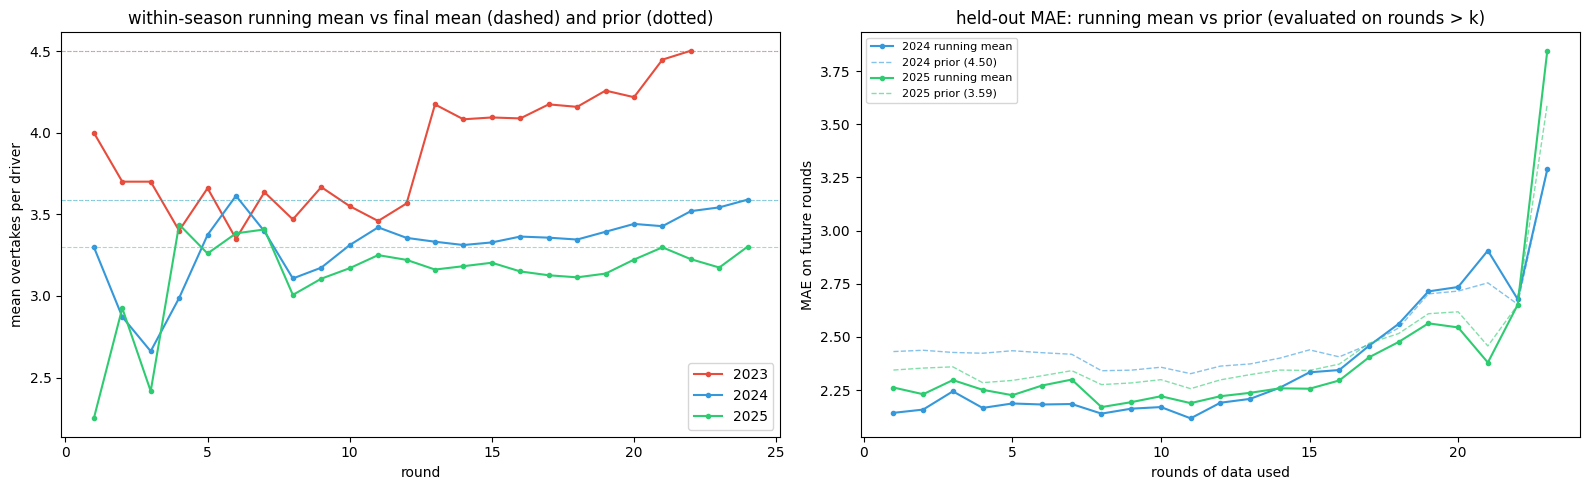

rounds until running mean stays within 5% of final season mean:
  2023: round 21  (running=4.45, final=4.50)
  2024: round 6  (running=3.61, final=3.59)
  2025: round 4  (running=3.44, final=3.30)


In [108]:
# how quickly does the within-season running mean stabilise vs the prior?
# evaluation is strictly held-out: at round k, both predictors are scored
# only against future rounds (k+1 onwards), not the data used to fit the running mean

seasons_to_test = [2023, 2024, 2025]
prior_map = {2023: None, 2024: season_means[2023], 2025: season_means[2024]}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# left: running mean trajectory per season
for season in seasons_to_test:
    season_ot = ot[ot['season'] == season].sort_values('round')
    final_mean = season_means[season]
    prior = prior_map[season]

    rounds = sorted(season_ot['round'].unique())
    running_means = [
        season_ot[season_ot['round'] <= r]['race_overtakes'].mean()
        for r in rounds
    ]

    colour = {'2023': '#e74c3c', '2024': '#3498db', '2025': '#2ecc71'}[str(season)]
    axes[0].plot(rounds, running_means, marker='o', markersize=3, linewidth=1.5,
                 label=str(season), color=colour)
    axes[0].axhline(final_mean, color=colour, linewidth=0.8, linestyle='--', alpha=0.5)
    if prior:
        axes[0].axhline(prior, color=colour, linewidth=0.8, linestyle=':', alpha=0.3)

axes[0].set_title('within-season running mean vs final mean (dashed) and prior (dotted)')
axes[0].set_xlabel('round')
axes[0].set_ylabel('mean overtakes per driver')
axes[0].legend()

# right: held-out MAE — both predictors evaluated only on rounds > k
for season in seasons_to_test:
    season_ot = ot[ot['season'] == season].sort_values('round')
    prior = prior_map[season]
    if prior is None:
        continue

    rounds = sorted(season_ot['round'].unique())
    mae_running, mae_prior, eval_rounds = [], [], []

    for r in rounds[:-1]:  # skip last round (no future data to evaluate on)
        future = season_ot[season_ot['round'] > r]['race_overtakes'].values
        if len(future) == 0:
            continue
        running_mean_k = season_ot[season_ot['round'] <= r]['race_overtakes'].mean()
        mae_running.append(np.abs(future - running_mean_k).mean())
        mae_prior.append(np.abs(future - prior).mean())
        eval_rounds.append(r)

    colour = {'2024': '#3498db', '2025': '#2ecc71'}[str(season)]
    axes[1].plot(eval_rounds, mae_running, marker='o', markersize=3, linewidth=1.5,
                 label=f'{season} running mean', color=colour)
    axes[1].plot(eval_rounds, mae_prior, linewidth=1, linestyle='--',
                 label=f'{season} prior ({prior:.2f})', color=colour, alpha=0.6)

axes[1].set_title('held-out MAE: running mean vs prior (evaluated on rounds > k)')
axes[1].set_xlabel('rounds of data used')
axes[1].set_ylabel('MAE on future rounds')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# print: after how many rounds does running mean stay within 5% of final mean?
print("rounds until running mean stays within 5% of final season mean:")
for season in seasons_to_test:
    season_ot = ot[ot['season'] == season].sort_values('round')
    final_mean = season_means[season]
    rounds = sorted(season_ot['round'].unique())
    for r in rounds:
        rm = season_ot[season_ot['round'] <= r]['race_overtakes'].mean()
        if abs(rm - final_mean) / final_mean <= 0.05:
            print(f"  {season}: round {r}  (running={rm:.2f}, final={final_mean:.2f})")
            break

## Validation: does adding overtakes close the target gap?

Using 2026 R5 (Canada) as the validation case where we have both computed targets and real scores.

In [109]:
# 2026 R5 race overtakes (from screenshot, manually verified)
r5_2026_race_ot = {
    'max_verstappen': 1, 'charles_leclerc': 2, 'george_russell': 5,
    'esteban_ocon': 2, 'oliver_bearman': 1, 'carlos_sainz': 3,
    'lewis_hamilton': 2, 'lando_norris': 9, 'pierre_gasly': 3,
    'fernando_alonso': 3, 'gabriel_bortoleto': 3, 'isack_hadjar': 0,
    'franco_colapinto': 4, 'sergio_perez': 4, 'arvid_lindblad': 0,
    'andrea_kimi_antonelli': 5, 'liam_lawson': 1, 'alexander_albon': 6,
    'nico_hulkenberg': 3, 'oscar_piastri': 6, 'lance_stroll': 1,
    'valtteri_bottas': 1,
}
# 2026 R5 sprint overtakes
r5_2026_sprint_ot = {
    'max_verstappen': 0, 'alexander_albon': 3, 'andrea_kimi_antonelli': 2,
    'sergio_perez': 3, 'esteban_ocon': 2, 'liam_lawson': 4,
    'lance_stroll': 2, 'franco_colapinto': 4, 'fernando_alonso': 1,
    'lewis_hamilton': 1, 'isack_hadjar': 0, 'nico_hulkenberg': 3,
    'carlos_sainz': 0, 'pierre_gasly': 3, 'george_russell': 1,
    'gabriel_bortoleto': 2, 'charles_leclerc': 1, 'oscar_piastri': 1,
    'oliver_bearman': 1, 'arvid_lindblad': 0, 'valtteri_bottas': 2,
    'lando_norris': 1,
}
# real 2026 R5 fantasy points (from F1 Fantasy app)
r5_real = {
    'max_verstappen': 26, 'charles_leclerc': 27, 'george_russell': 4,
    'esteban_ocon': 8, 'oliver_bearman': 10, 'carlos_sainz': 11,
    'lewis_hamilton': 42, 'lando_norris': 6, 'pierre_gasly': 16,
    'fernando_alonso': -26, 'gabriel_bortoleto': 5, 'isack_hadjar': 6,
    'franco_colapinto': 25, 'sergio_perez': -11, 'arvid_lindblad': -16,
    'andrea_kimi_antonelli': 62, 'liam_lawson': 23, 'alexander_albon': -8,
    'nico_hulkenberg': 1, 'oscar_piastri': 12, 'lance_stroll': 11,
    'valtteri_bottas': 12,
}

computed = pd.read_parquet('../data/processed/targets/2026_05.parquet')
computed = (
    computed[computed['asset_type'] == 'driver']
    .rename(columns={'asset_id': 'driver_id'})
    .set_index('driver_id')['actual_fantasy_points']
)

val = pd.DataFrame({
    'computed': computed,
    'race_ot': pd.Series(r5_2026_race_ot),
    'sprint_ot': pd.Series(r5_2026_sprint_ot),
    'real': pd.Series(r5_real),
}).dropna()

val['adjusted'] = val['computed'] + val['race_ot'] + val['sprint_ot']
# hamilton DOTD +10
val.loc['lewis_hamilton', 'adjusted'] += 10

val['gap_before'] = val['real'] - val['computed']
val['gap_after'] = val['real'] - val['adjusted']

print(val[['computed', 'race_ot', 'sprint_ot', 'adjusted', 'real', 'gap_before', 'gap_after']]
      .sort_values('real', ascending=False)
      .to_string())

print(f"\nMAE before overtakes: {val['gap_before'].abs().mean():.2f}")
print(f"MAE after overtakes:  {val['gap_after'].abs().mean():.2f}")
print(f"Perfect matches after: {(val['gap_after'] == 0).sum()}/{len(val)}")

                       computed  race_ot  sprint_ot  adjusted  real  gap_before  gap_after
andrea_kimi_antonelli      55.0        5          2      62.0    62         7.0        0.0
lewis_hamilton             29.0        2          1      42.0    42        13.0        0.0
charles_leclerc            24.0        2          1      27.0    27         3.0        0.0
max_verstappen             25.0        1          0      26.0    26         1.0        0.0
franco_colapinto           17.0        4          4      25.0    25         8.0        0.0
liam_lawson                18.0        1          4      23.0    23         5.0        0.0
pierre_gasly               10.0        3          3      16.0    16         6.0        0.0
oscar_piastri               5.0        6          1      12.0    12         7.0        0.0
valtteri_bottas             9.0        1          2      12.0    12         3.0        0.0
carlos_sainz                8.0        3          0      11.0    11         3.0        0.0

## Walk-forward evaluation: career average vs rolling N driver index

For each driver-race, predict using only data strictly before that race — then compare against actual.

Two components are held fixed across both methods (to isolate the driver index effect):
- **circuit_index** — pre-computed from all available data (same for both)
- **season baseline** — prior season mean only (no current-season leakage)

Only the **driver index** varies: career all-time average vs rolling last N races.

In [18]:
# prior season baseline: use mean of all prior seasons to avoid current-season leakage
prior_baseline = {}
for s in sorted(ot['season'].unique()):
    prev = ot[ot['season'] < s]
    prior_baseline[s] = prev['race_overtakes'].mean() if len(prev) > 0 else ot[ot['season'] == s]['race_overtakes'].mean()

print("Prior season baselines:", {s: round(v, 2) for s, v in prior_baseline.items()})

# attach location to overtake history (all seasons)
ot_loc = ot.merge(round_location.reset_index(), on=['season', 'round'], how='left')

N_VALUES = [3, 5, 10, 15]
rows = []

for _, row in ot_loc.iterrows():
    driver   = row['driver_id']
    season   = row['season']
    round_   = row['round']
    location = row.get('location')
    actual   = row['race_overtakes']

    # strictly prior races for this driver
    prior = ot_loc[
        (ot_loc['driver_id'] == driver) &
        ((ot_loc['season'] < season) |
         ((ot_loc['season'] == season) & (ot_loc['round'] < round_)))
    ].copy()

    if len(prior) == 0:
        continue  # skip: no prior data to build an index from

    # season-normalise prior overtakes using within-prior-data season means
    s_means_prior = prior.groupby('season')['race_overtakes'].mean()
    prior['ot_idx'] = prior.apply(lambda r: r['race_overtakes'] / s_means_prior[r['season']], axis=1)

    c      = c_idx.get(location, 1.0) if pd.notna(location) else 1.0
    s_mean = prior_baseline[season]

    rec = {
        'driver': driver, 'season': season, 'round': round_,
        'location': location, 'actual': actual,
        'career': prior['ot_idx'].mean() * c * s_mean,
    }
    for N in N_VALUES:
        rec[f'rolling_{N}'] = prior.tail(N)['ot_idx'].mean() * c * s_mean

    rows.append(rec)

eval_df = pd.DataFrame(rows)

methods = ['career'] + [f'rolling_{N}' for N in N_VALUES]
print(f"\nWalk-forward MAE  (n={len(eval_df)} driver-races, rookie first race excluded)\n")
print(f"  {'method':<14}  {'MAE':>6}  {'bias':>7}")
print(f"  {'-'*32}")
for m in methods:
    err = eval_df[m] - eval_df['actual']
    print(f"  {m:<14}  {err.abs().mean():>6.3f}  {err.mean():>+7.3f}")

Prior season baselines: {np.int64(2023): np.float64(4.5), np.int64(2024): np.float64(4.5), np.int64(2025): np.float64(4.03), np.int64(2026): np.float64(3.78)}


C:\Users\gputs\AppData\Local\Temp\ipykernel_29032\1584991329.py:34: RuntimeWarning: invalid value encountered in scalar divide
  prior['ot_idx'] = prior.apply(lambda r: r['race_overtakes'] / s_means_prior[r['season']], axis=1)
C:\Users\gputs\AppData\Local\Temp\ipykernel_29032\1584991329.py:34: RuntimeWarning: invalid value encountered in scalar divide
  prior['ot_idx'] = prior.apply(lambda r: r['race_overtakes'] / s_means_prior[r['season']], axis=1)
C:\Users\gputs\AppData\Local\Temp\ipykernel_29032\1584991329.py:34: RuntimeWarning: invalid value encountered in scalar divide
  prior['ot_idx'] = prior.apply(lambda r: r['race_overtakes'] / s_means_prior[r['season']], axis=1)
C:\Users\gputs\AppData\Local\Temp\ipykernel_29032\1584991329.py:34: RuntimeWarning: invalid value encountered in scalar divide
  prior['ot_idx'] = prior.apply(lambda r: r['race_overtakes'] / s_means_prior[r['season']], axis=1)
C:\Users\gputs\AppData\Local\Temp\ipykernel_29032\1584991329.py:34: RuntimeWarning: invalid 


Walk-forward MAE  (n=1479 driver-races, rookie first race excluded)

  method             MAE     bias
  --------------------------------
  career           2.372   +0.402
  rolling_3        2.729   +0.648
  rolling_5        2.597   +0.666
  rolling_10       2.468   +0.609
  rolling_15       2.441   +0.552


In [19]:
# per-driver breakdown: which drivers benefit most from rolling vs career?
# use whichever rolling window had the best overall MAE above
best_rolling = min([f'rolling_{N}' for N in N_VALUES], key=lambda m: (eval_df[m] - eval_df['actual']).abs().mean())
print(f"Best rolling method overall: {best_rolling}\n")

per_driver = []
for driver, grp in eval_df.groupby('driver'):
    if len(grp) < 10:
        continue
    career_mae   = (grp['career']       - grp['actual']).abs().mean()
    rolling_mae  = (grp[best_rolling]   - grp['actual']).abs().mean()
    career_bias  = (grp['career']       - grp['actual']).mean()
    rolling_bias = (grp[best_rolling]   - grp['actual']).mean()
    per_driver.append({
        'driver':        driver,
        'n':             len(grp),
        'career_mae':    round(career_mae,  2),
        'rolling_mae':   round(rolling_mae, 2),
        'improvement':   round(career_mae - rolling_mae, 2),
        'career_bias':   round(career_bias,  2),
        'rolling_bias':  round(rolling_bias, 2),
    })

per_driver_df = (
    pd.DataFrame(per_driver)
    .sort_values('improvement', ascending=False)
    .reset_index(drop=True)
)

print(f"Per-driver MAE: career vs {best_rolling}  (min 10 races, sorted by improvement)\n")
print(per_driver_df.to_string(index=False))

Best rolling method overall: rolling_15

Per-driver MAE: career vs rolling_15  (min 10 races, sorted by improvement)

               driver  n  career_mae  rolling_mae  improvement  career_bias  rolling_bias
          liam_lawson 39        2.09         2.02         0.07         0.76          0.60
         esteban_ocon 73        2.36         2.32         0.03        -0.01          0.19
         sergio_perez 50        2.69         2.67         0.03        -0.99         -0.74
      valtteri_bottas 50        2.10         2.08         0.02         1.23          1.22
andrea_kimi_antonelli 28        2.13         2.11         0.02         0.36          0.32
      kevin_magnussen 43        2.20         2.20        -0.00        -0.48         -0.54
       oliver_bearman 30        2.51         2.52        -0.00        -1.24         -1.23
          zhou_guanyu 45        2.25         2.25        -0.00         0.63          0.55
      nico_hulkenberg 74        2.54         2.56        -0.01         0

## Next steps

Automate overtake data using telemetry